<a href="https://colab.research.google.com/github/ahmedgomaa512/Cat-Dog-Classification/blob/main/Cat_Dog_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
import os

### 1 - Loading Data

In [4]:
base_dir = r"C:\Users\GASCO\Desktop\Assignment Lab\Cats Dogs Classification\dataset_split"
train_cats_path = os.path.join(base_dir, "train/Cat")
print("Train Cat images:", len(os.listdir(train_cats_path)))
print("Val Cat images:", len(os.listdir(os.path.join(base_dir,"val/Cat"))))
print("Test Cat images:", len(os.listdir(os.path.join(base_dir,"test/Cat"))))
img_list = os.listdir(train_cats_path)
type(img_list)
type(img_list[0])

Train Cat images: 8749
Val Cat images: 2793
Test Cat images: 2793


str

In [5]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras import models, layers

# Parameters
IMG_SIZE = (64, 64)  # Resize images
base_dir = r"C:\Users\GASCO\Desktop\Assignment Lab\Cats Dogs Classification\dataset_split"

def load_images_and_labels(folder):
    X = []
    y = []
    for label, category in enumerate(["Cat", "Dog"]):  # Cat=0, Dog=1
        category_folder = os.path.join(folder, category)
        for file in os.listdir(category_folder):
            try:
                img = Image.open(os.path.join(category_folder, file)).convert('RGB')
                img = img.resize(IMG_SIZE)
                img_array = np.array(img)
                X.append(img_array)
                y.append(label)
            except:
                pass
    return np.array(X), np.array(y)

# Load datasets
X_train, y_train = load_images_and_labels(os.path.join(base_dir, "train"))
X_val, y_val = load_images_and_labels(os.path.join(base_dir, "val"))
X_test, y_test = load_images_and_labels(os.path.join(base_dir, "test"))


print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

c:\Users\GASCO\anaconda3\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Train shape: (17498, 64, 64, 3) (17498,)
Val shape: (5595, 64, 64, 3) (5595,)
Test shape: (5595, 64, 64, 3) (5595,)


### 2 - Understanding Data

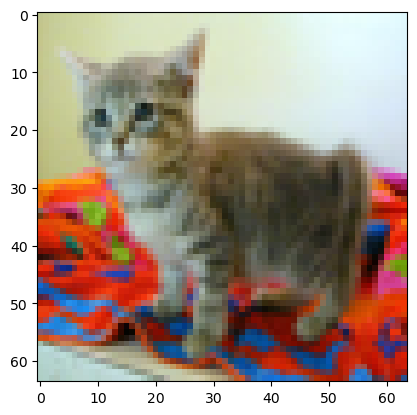

In [6]:
# Visualize one image
imgshow = plt.imshow(X_train[44], cmap = "gray")
imgshow

In [7]:
#Understand labels
np.unique (y_train)

array([0, 1])

### 3 - Flatten Data and Normalize it

In [8]:
#Flatten data and normalize it
X_train = X_train.reshape (X_train.shape [0],-1) / 255.0
X_val = X_val.reshape (X_val.shape [0],-1) / 255.0
X_test = X_test.reshape (X_test.shape [0],-1) / 255.0

In [9]:
print("Train Flattened shape:", X_train.shape, y_train.shape)
print("Val Flattened shape:", X_val.shape, y_val.shape)
print("Test Flattened shape:", X_test.shape, y_test.shape)

Train Flattened shape: (17498, 12288) (17498,)
Val Flattened shape: (5595, 12288) (5595,)
Test Flattened shape: (5595, 12288) (5595,)


### 4 - Bulding ML Models

In [10]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import joblib



# ---------------- CLASSIFIERS ----------------
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

results = []

### 6 - Train Models

In [11]:
# ---------------- TRAIN & EVALUATE ----------------
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)
    
    val_acc = accuracy_score(y_val, val_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    print(f"{name} -> Validation Accuracy: {val_acc*100:.2f}% | Test Accuracy: {test_acc*100:.2f}%")
    results.append((name, val_acc, test_acc))


Training Random Forest...
Random Forest -> Validation Accuracy: 65.24% | Test Accuracy: 65.56%

Training Logistic Regression...


c:\Users\GASCO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression -> Validation Accuracy: 56.71% | Test Accuracy: 56.51%

Training K-Nearest Neighbors...
K-Nearest Neighbors -> Validation Accuracy: 57.43% | Test Accuracy: 57.59%

Training Decision Tree...
Decision Tree -> Validation Accuracy: 56.48% | Test Accuracy: 56.43%


### 7 - Choosing Best Model

In [12]:
# ---------------- BEST MODEL ----------------
results_sorted = sorted(results, key=lambda x: x[2], reverse=True)  # sort by test accuracy
best_model_name, best_val_acc, best_test_acc = results_sorted[0]
print(f"\nBest Model: {best_model_name} with Test Accuracy: {best_test_acc*100:.2f}%")


Best Model: Random Forest with Test Accuracy: 65.56%


### 8 - SAVE BEST MODEL

In [14]:
# ---------------- SAVE BEST MODEL ----------------
import joblib


best_model = models[best_model_name] 
joblib.dump(best_model, "model.pkl")


['model.pkl']

### 9 - Download Best Model

In [ ]:
from google.colab import files
files.download("best_cat_dog_model.keras")